# Single-component model vs observed data

Journal-style figure matching `model_and_data.ipynb`, but for **one** transport component:

$$C(t) = R \, E(t; \mathrm{MRT}, \mathrm{Pe})$$

Uses `single_component/outputs/phase_exploration/exploration_ensemble.csv` for comparable-good-fit uncertainty bands (2.5–97.5% across elite runs) and the best row for the main curve.

## 1) Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2) Model setup and load data

In [2]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

from reactive_transport.simulation_options_2 import simulateDualPorosity


def load_data(csv_path):
    df = pd.read_csv(csv_path)
    weights = df["weight"].to_numpy()
    mask = weights.astype(bool)
    t_true = df["Time_hr"].to_numpy()[mask]
    c_true = df["C_corr_mgL"].to_numpy()[mask]
    return t_true, c_true


def modelRELAP(t, mrt, pec):
    frac_retard = 1.0
    bckgrnd_conc = 0.0
    inj_concs = np.array([7.0, 0.0], dtype=float)
    inj_durs = np.cumsum(np.array([1.5], dtype=float))
    dpParam = 0
    matrix_retardation = 1.0
    recRatio = 0.0
    wsCoef = 0.0
    return simulateDualPorosity(
        mrt,
        pec,
        frac_retard,
        t,
        bckgrnd_conc,
        inj_concs,
        inj_durs,
        dpParam,
        matrix_retardation,
        recRatio=recRatio,
        wsCoef=wsCoef,
        delay_time=0,
    )


ensemble_csv = repo_root / "single_component/outputs/phase_exploration/exploration_ensemble.csv"
ensemble = pd.read_csv(ensemble_csv)
t_true, c_true = load_data(str(repo_root / "data/data.csv"))

## 3) Elite ensemble curves and percentile bands

Stack predictions from the **top N** exploration runs (lowest `J_m`). Bands are 2.5–97.5% across those curves (same interpretation as the two-component notebook).

In [3]:
N_best = min(1024, len(ensemble))
elite = ensemble.nsmallest(N_best, "J_m")

t_plot = np.linspace(0.01, 130.0, 250)

curves = []
for _, row in elite.iterrows():
    R = float(row["best_R"])
    mrt = float(row["best_MRT"])
    pec = float(row["best_Pe"])
    e = np.asarray(modelRELAP(t_plot, mrt, pec), dtype=float)
    curves.append(R * e)

curves = np.vstack(curves)


def band_stats(curves_arr):
    mean_y = np.mean(curves_arr, axis=0)
    lo_y = np.percentile(curves_arr, 2.5, axis=0)
    hi_y = np.percentile(curves_arr, 97.5, axis=0)
    return mean_y, lo_y, hi_y


mean_pred, lo_pred, hi_pred = band_stats(curves)

## 4) Journal-style figure: best fit + CI band + data

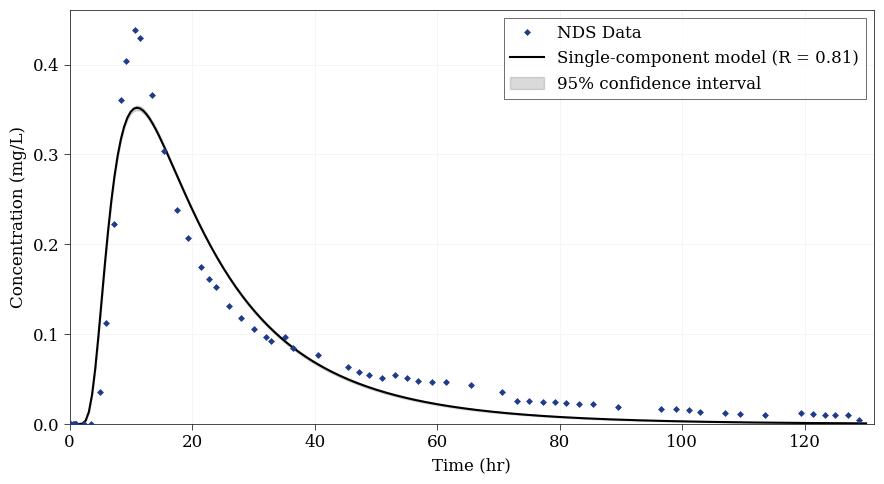

In [ ]:
best_elite = elite.iloc[0]

c_best = float(best_elite["best_R"]) * np.asarray(
    modelRELAP(t_plot, float(best_elite["best_MRT"]), float(best_elite["best_Pe"])),
    dtype=float,
)

_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    h_ci = ax.fill_between(t_plot, lo_pred, hi_pred, color="0.35", alpha=0.22)
    h_line, = ax.plot(t_plot, c_best, color="black", linewidth=_pt)

    h_nds, = ax.plot(
        t_true,
        c_true,
        linestyle="None",
        marker="D",
        markersize=3,
        markerfacecolor="#1f3c88",
        markeredgecolor="#1f3c88",
        markeredgewidth=_pt_hair,
        zorder=5,
    )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("Concentration (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    x_hi = max(float(np.max(t_plot)), float(np.max(t_true)))
    y_hi = float(np.nanmax([hi_pred.max(), float(np.max(c_true))]))
    ax.set_xlim(0, x_hi * 1.01)
    ax.set_ylim(0, y_hi * 1.05)

    R_best = float(best_elite["best_R"])
    leg_handles = [h_nds, h_line, h_ci]
    leg_labels = [
        "NDS Data",
        f"Single-component model (R = {R_best:.2f})",
        "95% confidence interval",
    ]
    leg = ax.legend(
        leg_handles,
        leg_labels,
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="black",
        fancybox=False,
    )
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    fig.savefig(
        "../Figures/single_component_model_and_data.pdf",
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.25,
    )

    plt.show()

In [6]:
ensemble.sort_values(by='J_m', ascending=True)

,run_idx,seed,best_R,best_MRT,best_Pe,J_m
19,20,120,0.809909,23.579321,3.205977,0.212137
21,22,122,0.808197,23.528596,3.214045,0.212138
61,62,162,0.809702,23.550108,3.213873,0.212139
49,50,150,0.808155,23.528741,3.219905,0.212139
59,60,160,0.809991,23.636525,3.190180,0.212140
...,...,...,...,...,...,...
33,34,134,0.815508,23.611515,3.201061,0.212237
6,7,107,0.808035,23.325695,3.280088,0.212240
54,55,155,0.814727,23.589723,3.216552,0.212243
39,40,140,0.796720,23.029230,3.334989,0.212306


In [7]:
ensemble.describe()

,run_idx,seed,best_R,best_MRT,best_Pe,J_m
count,64.000000,64.000000,64.000000,64.000000,64.000000,64.000000
mean,32.500000,132.500000,0.809108,23.560313,3.209190,0.212182
std,18.618987,18.618987,0.004111,0.191601,0.041827,0.000039
min,1.000000,101.000000,0.796720,23.029230,3.138219,0.212137
25%,16.750000,116.750000,0.806620,23.443850,3.176121,0.212156
50%,32.500000,132.500000,0.809806,23.562382,3.210490,0.212171
75%,48.250000,148.250000,0.812142,23.697242,3.232461,0.212196
max,64.000000,164.000000,0.815508,23.917881,3.334989,0.212353
